[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/automation/repair-pypsa-earth-norway/notebooks/energyopt/PyPSA-Earth_Norway.ipynb)

# Norway power-system modelling with PyPSA-Earth concepts and NeqSim

This notebook connects a compact Norway-like electricity model to an offshore
gas-processing load calculated with NeqSim. It preserves the original two examples:

1. configure and solve a Norway PyPSA-Earth-style network; and
2. connect a 100 MW offshore facility through a 95%-efficient power-from-shore cable.

The full PyPSA-Earth workflow is a Snakemake project with geospatial data preparation,
not a pypsa-earth command or a small PyPI library. For a reproducible Colab lesson,
this notebook uses an explicitly synthetic four-bus network that follows PyPSA-Earth
component conventions. It does not claim to reproduce the Norwegian grid.

Background: [PyPSA-Earth](https://github.com/pypsa-meets-earth/pypsa-earth) and the
original [NMBU thesis](https://nmbu.brage.unit.no/nmbu-xmlui/handle/11250/3188543).

## Engineering context

Norway has hydro-dominated generation, growing wind capacity, and constrained
regional corridors. Offshore electrification adds a large, nearly continuous load.
The engineering question is whether supply and transfer capacity can serve every
hour, not merely whether annual energy is sufficient.

This model represents mainland areas NO1, NO2, and NO5 plus an offshore bus.
Capacities and profiles are transparent synthetic teaching assumptions. Use official
Statnett, NVE, and PyPSA-Earth datasets for project decisions.

## Learning objectives and equations

You will learn to:

- translate a country configuration into PyPSA components;
- solve hourly dispatch with the current Network.optimize API and HiGHS;
- interpret dispatch, corridor loading, cable losses, and marginal prices;
- build a NeqSim Stream–Compressor–Cooler–Separator process;
- transfer calculated process power into PyPSA; and
- check mass, electrical balance, capacity, finite values, and trends.

At each bus and hour, PyPSA enforces

$$

\sum_g P_{g,t} - P_{\mathrm{load},t} - P_{\mathrm{export},t} = 0.

$$

For cable efficiency $\eta_{\mathrm{cable}}$,

$$

P_{\mathrm{in}} =
\frac{P_{\mathrm{offshore}}}{\eta_{\mathrm{cable}}}.

$$

All power terms are MW. NeqSim calculates compressor power; Python only transfers
the returned value to the power-system model.

## Colab-compatible setup

Released packages are installed from public PyPI only when missing. A full
PyPSA-Earth study should instead use its locked environment and Snakemake workflow.

In [1]:
import importlib.util
import logging
import os
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-neqsim-pypsa")

required_imports = {
    "neqsim": "neqsim",
    "pypsa": "pypsa",
    "highspy": "highspy",
    "yaml": "PyYAML",
}
missing_packages = [
    package
    for import_name, package in required_imports.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-cache-dir",
        *missing_packages,
    ]
    subprocess.run(command, check=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import yaml
from IPython.display import display

logging.getLogger("linopy").setLevel(logging.ERROR)
logging.getLogger("pypsa").setLevel(logging.ERROR)

COLORS = {
    "blue": "#0072B2",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "purple": "#CC79A7",
}

print(f"PyPSA version: {pypsa.__version__}")

PyPSA version: 1.2.4


## Preserve the Norway configuration workflow

The original notebook wrote YAML after cloning a repository. A shell cd does not
persist between Colab cells, and current PyPSA-Earth is a versioned Snakemake
workflow. The country, ISO code, cutout, renewables, and solver intent are retained
below as an auditable in-memory configuration.

In [2]:
norway_config = {
    "version": 0.2,
    "countries": ["NO"],
    "country_code": "NOR",
    "snapshots": {
        "start": "2026-01-15 00:00",
        "periods": 24,
        "frequency": "h",
    },
    "renewable": {
        "onwind": True,
        "offwind": True,
        "hydro": True,
    },
    "cutout": {
        "name": "norway-era5",
        "module": "era5",
        "years": [2026],
    },
    "solver": {
        "name": "highs",
    },
}

print(yaml.safe_dump(norway_config, sort_keys=False))

version: 0.2
countries:
- 'NO'
country_code: NOR
snapshots:
  start: 2026-01-15 00:00
  periods: 24
  frequency: h
renewable:
  onwind: true
  offwind: true
  hydro: true
cutout:
  name: norway-era5
  module: era5
  years:
  - 2026
solver:
  name: highs



## Build and solve the compact Norway-like network

The original pypsa-earth CLI call did not exist. Official PyPSA-Earth uses Snakemake
to create a PyPSA Network from large open datasets. The function below makes the
handoff explicit with hydro in NO5, wind in NO2, backup and imports in NO1, three
finite AC corridors, and a configurable offshore link and load. It uses the current
Network.optimize interface.

In [3]:
def build_norway_network(
    offshore_load_mw=100.0,
    cable_efficiency=0.95,
    cable_margin=1.08,
):
    network = pypsa.Network()
    snapshots = pd.date_range(
        norway_config["snapshots"]["start"],
        periods=norway_config["snapshots"]["periods"],
        freq=norway_config["snapshots"]["frequency"],
        name="snapshot",
    )
    network.set_snapshots(snapshots)

    coordinates = {
        "NO1": (10.75, 59.91),
        "NO2": (7.00, 58.15),
        "NO5": (5.32, 60.39),
        "Offshore": (2.50, 58.80),
    }
    network.add("Carrier", "AC")
    network.add("Carrier", "hydro", co2_emissions=0.0)
    network.add("Carrier", "wind", co2_emissions=0.0)
    network.add("Carrier", "gas", co2_emissions=0.37)
    network.add("Carrier", "import", co2_emissions=0.05)

    for name, location in coordinates.items():
        longitude, latitude = location
        network.add(
            "Bus",
            name,
            x=longitude,
            y=latitude,
            carrier="AC",
        )

    hour = np.arange(len(snapshots))
    load_shape = (
        0.93
        + 0.11 * np.cos(2.0 * np.pi * (hour - 18.0) / 24.0)
        + 0.04 * np.cos(4.0 * np.pi * (hour - 8.0) / 24.0)
    )
    wind_profile = (
        0.48
        + 0.22 * np.sin(2.0 * np.pi * (hour + 3.0) / 24.0)
        + 0.08 * np.sin(4.0 * np.pi * hour / 24.0)
    )
    wind_profile = np.clip(wind_profile, 0.15, 0.82)
    hydro_profile = np.full(len(snapshots), 0.92)

    base_loads_mw = {
        "NO1": 3000.0,
        "NO2": 1500.0,
        "NO5": 1100.0,
    }
    for bus_name, base_load_mw in base_loads_mw.items():
        network.add(
            "Load",
            f"{bus_name} demand",
            bus=bus_name,
            p_set=base_load_mw * load_shape,
        )

    network.add(
        "Load",
        "Offshore facility",
        bus="Offshore",
        p_set=float(offshore_load_mw),
    )
    network.add(
        "Generator",
        "NO5 hydro",
        bus="NO5",
        carrier="hydro",
        p_nom=4400.0,
        marginal_cost=12.0,
        p_max_pu=hydro_profile,
    )
    network.add(
        "Generator",
        "NO2 wind",
        bus="NO2",
        carrier="wind",
        p_nom=2600.0,
        marginal_cost=4.0,
        p_max_pu=wind_profile,
    )
    network.add(
        "Generator",
        "NO1 gas backup",
        bus="NO1",
        carrier="gas",
        p_nom=2600.0,
        marginal_cost=90.0,
    )
    network.add(
        "Generator",
        "NO1 imports",
        bus="NO1",
        carrier="import",
        p_nom=2200.0,
        marginal_cost=115.0,
    )

    corridor_data = [
        ("NO5-NO2", "NO5", "NO2", 1800.0, 0.08),
        ("NO2-NO1", "NO2", "NO1", 2400.0, 0.08),
        ("NO5-NO1", "NO5", "NO1", 1200.0, 0.10),
    ]
    for line_name, bus0, bus1, capacity_mw, reactance in corridor_data:
        network.add(
            "Line",
            line_name,
            bus0=bus0,
            bus1=bus1,
            carrier="AC",
            s_nom=capacity_mw,
            x=reactance,
            r=0.01,
        )

    cable_input_mw = float(offshore_load_mw) / cable_efficiency
    cable_capacity_mw = max(120.0, cable_input_mw * cable_margin)
    network.add(
        "Link",
        "Power from shore cable",
        bus0="NO2",
        bus1="Offshore",
        carrier="AC",
        p_nom=cable_capacity_mw,
        efficiency=cable_efficiency,
        p_min_pu=0.0,
        marginal_cost=1.5,
    )

    status, condition = network.optimize(
        solver_name="highs",
        log_to_console=False,
        include_objective_constant=False,
    )
    if status != "ok" or condition != "optimal":
        raise RuntimeError(
            f"Optimization failed: status={status}, condition={condition}"
        )
    return network


norway_network = build_norway_network()
print(
    "Optimization passed:",
    norway_network.model.status,
    norway_network.model.termination_condition,
)

Optimization passed: ok optimal


## Norwegian scenarios represented

The compact model retains the original scenario ideas: hourly renewable availability,
regional transfer bottlenecks, backup generation, imports, a 100 MW offshore case,
and later sensitivity to process-derived load. This is operational dispatch, not a
capacity-expansion forecast.

## Reading the result

PyPSA writes dispatch to generators_t.p, line flow to lines_t.p0, cable input to
links_t.p0, and marginal prices to buses_t.marginal_price. A marginal price is the
modeled cost of one additional MWh under these assumptions, not a market forecast.

## Preserved example: powering a 100 MW offshore field

The original example combined a 100 MW load with a 100 MW link at 95% efficiency,
which could deliver only 95 MW. The repaired case keeps the 100 MW demand and sizes
the mainland-side rating above $100 / 0.95 = 105.263$ MW. Link p0 is mainland input;
minus p1 is offshore delivery.

In [4]:
offshore_link = "Power from shore cable"
offshore_load = norway_network.loads_t.p["Offshore facility"]
cable_input = norway_network.links_t.p0[offshore_link]
cable_output = -norway_network.links_t.p1[offshore_link]
cable_capacity = float(norway_network.links.at[offshore_link, "p_nom"])

offshore_summary = pd.DataFrame(
    {
        "metric": [
            "Offshore demand",
            "Mainland cable input",
            "Offshore cable output",
            "Cable input rating",
            "Peak cable utilization",
        ],
        "value": [
            offshore_load.max(),
            cable_input.max(),
            cable_output.max(),
            cable_capacity,
            cable_input.max() / cable_capacity,
        ],
        "unit": ["MW", "MW", "MW", "MW", "fraction"],
    }
)

assert np.allclose(cable_output, offshore_load, atol=1.0e-8)
assert cable_input.max() <= cable_capacity + 1.0e-8
display(offshore_summary)

,metric,value,unit
0,Offshore demand,100.000000,MW
1,Mainland cable input,105.263158,MW
2,Offshore cable output,100.000000,MW
3,Cable input rating,120.000000,MW
4,Peak cable utilization,0.877193,fraction


The offshore bus closes exactly. The 5.263 MW difference between mainland input and
offshore delivery is modeled cable loss. Remaining input rating is design headroom.

## Workflow overview

NeqSim owns fluid properties, compression duty, temperature, phases, and material
closure. PyPSA owns generation dispatch, transmission, cable loss, and marginal
electricity cost. Compressor shaft power in MW is the interface.

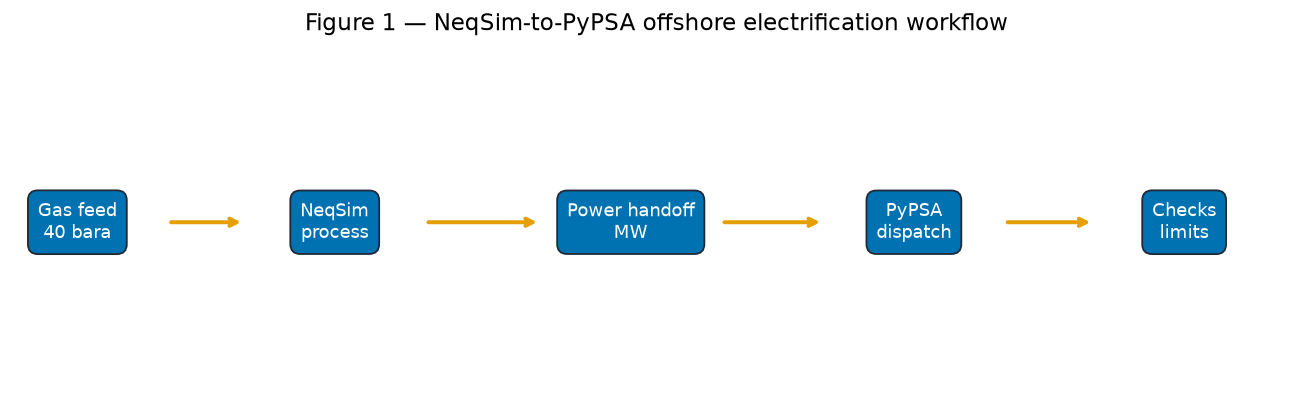

In [5]:
fig, ax = plt.subplots(figsize=(10.2, 3.2))
ax.set_xlim(0.0, 10.0)
ax.set_ylim(0.0, 3.0)
ax.axis("off")

blocks = [
    (0.5, "Gas feed\n40 bara"),
    (2.5, "NeqSim\nprocess"),
    (4.8, "Power handoff\nMW"),
    (7.0, "PyPSA\ndispatch"),
    (9.1, "Checks\nlimits"),
]
for position, label in blocks:
    ax.text(
        position,
        1.5,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": COLORS["blue"],
            "edgecolor": "#1F2937",
        },
    )

for left_block, right_block in zip(blocks[:-1], blocks[1:]):
    ax.annotate(
        "",
        xy=(right_block[0] - 0.7, 1.5),
        xytext=(left_block[0] + 0.7, 1.5),
        arrowprops={
            "arrowstyle": "->",
            "color": COLORS["orange"],
            "lw": 2.2,
        },
    )

ax.set_title(
    "Figure 1 — NeqSim-to-PyPSA offshore electrification workflow",
    fontsize=13,
    pad=14,
)
plt.tight_layout()
plt.show()

Figure 1 makes the model boundary explicit. Thermodynamic power is retrieved from
NeqSim and used as an input; no compressor equation is reimplemented in Python.

## Network topology and corridor loading

Line labels show maximum 24-hour flow as a percentage of rating. The offshore cable
is dashed because it is a directional link with explicit efficiency.

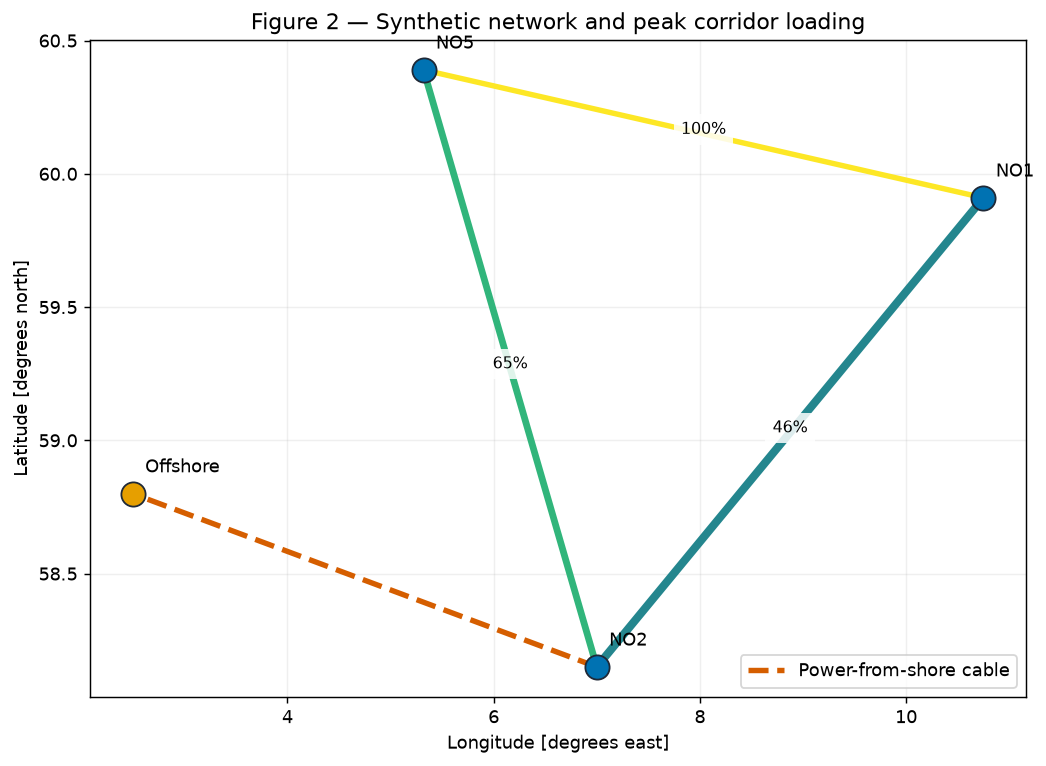

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 6.0))
coordinates = norway_network.buses[["x", "y"]]
line_utilization = (
    norway_network.lines_t.p0.abs().max()
    / norway_network.lines["s_nom"]
)

for line_name, line in norway_network.lines.iterrows():
    start = coordinates.loc[line["bus0"]]
    end = coordinates.loc[line["bus1"]]
    utilization = float(line_utilization.loc[line_name])
    ax.plot(
        [start["x"], end["x"]],
        [start["y"], end["y"]],
        color=plt.cm.viridis(utilization),
        linewidth=1.5 + 3.0 * line["s_nom"] / 2400.0,
        solid_capstyle="round",
    )
    midpoint_x = (start["x"] + end["x"]) / 2.0
    midpoint_y = (start["y"] + end["y"]) / 2.0
    ax.text(
        midpoint_x,
        midpoint_y,
        f"{100.0 * utilization:.0f}%",
        ha="center",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "none",
        },
    )

cable = norway_network.links.loc[offshore_link]
cable_start = coordinates.loc[cable["bus0"]]
cable_end = coordinates.loc[cable["bus1"]]
ax.plot(
    [cable_start["x"], cable_end["x"]],
    [cable_start["y"], cable_end["y"]],
    color=COLORS["red"],
    linewidth=3.0,
    linestyle="--",
    label="Power-from-shore cable",
)

for bus_name, row in coordinates.iterrows():
    color = COLORS["orange"] if bus_name == "Offshore" else COLORS["blue"]
    ax.scatter(
        row["x"],
        row["y"],
        s=180,
        color=color,
        edgecolor="#1F2937",
        zorder=4,
    )
    ax.text(row["x"] + 0.12, row["y"] + 0.08, bus_name, fontsize=10)

ax.set_title("Figure 2 — Synthetic network and peak corridor loading")
ax.set_xlabel("Longitude [degrees east]")
ax.set_ylabel("Latitude [degrees north]")
ax.grid(alpha=0.2)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The NO5–NO1 corridor reaches its rating. The intended lesson is that low-cost energy
may exist nationally while transfer constraints change local dispatch and price.

## Hourly dispatch and electrical balance

The dispatch stack is compared with delivered load. Cable losses are included in
the numerical balance even though they are small on the plot.

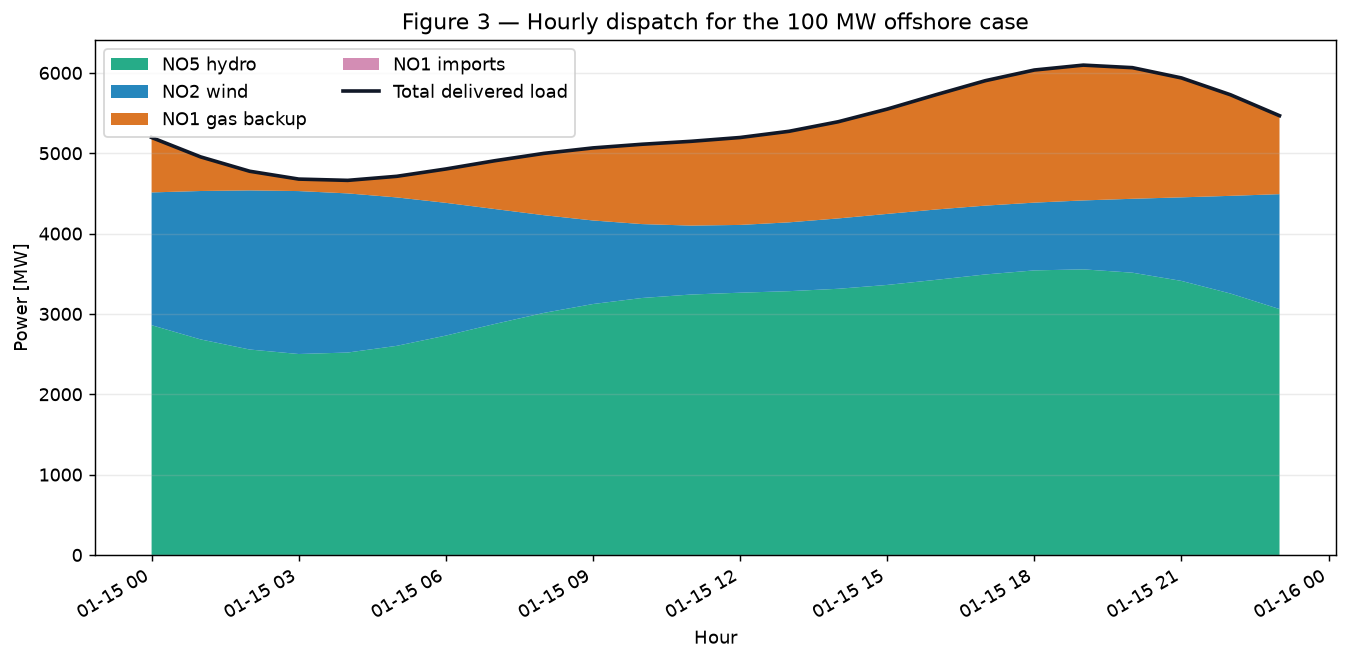

In [7]:
dispatch = norway_network.generators_t.p.copy()
total_load = norway_network.loads_t.p.sum(axis=1)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.stackplot(
    dispatch.index,
    [dispatch[column] for column in dispatch.columns],
    labels=list(dispatch.columns),
    colors=[
        COLORS["green"],
        COLORS["blue"],
        COLORS["red"],
        COLORS["purple"],
    ],
    alpha=0.85,
)
ax.plot(
    total_load.index,
    total_load,
    color="#111827",
    linewidth=2.0,
    label="Total delivered load",
)
ax.set_title("Figure 3 — Hourly dispatch for the 100 MW offshore case")
ax.set_xlabel("Hour")
ax.set_ylabel("Power [MW]")
ax.legend(loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Over the modeled horizon,

$$

E_{\mathrm{generation}}
- E_{\mathrm{load}}
- E_{\mathrm{cable\ loss}}
= 0.

$$

AC-line loss is outside this linear DC abstraction. Cable loss is explicit through
link efficiency.

In [8]:
generation_mwh = norway_network.generators_t.p.sum().sum()
load_mwh = norway_network.loads_t.p.sum().sum()
cable_loss_mwh = (
    norway_network.links_t.p0[offshore_link]
    + norway_network.links_t.p1[offshore_link]
).sum()
electrical_residual_mwh = generation_mwh - load_mwh - cable_loss_mwh

validation_table = pd.DataFrame(
    {
        "check": [
            "Termination",
            "Generation energy",
            "Delivered load energy",
            "Cable loss energy",
            "Electrical residual",
            "Maximum AC-line utilization",
        ],
        "value": [
            str(norway_network.model.termination_condition),
            generation_mwh,
            load_mwh,
            cable_loss_mwh,
            electrical_residual_mwh,
            line_utilization.max(),
        ],
        "unit": ["status", "MWh", "MWh", "MWh", "MWh", "fraction"],
    }
)

assert abs(electrical_residual_mwh) < 1.0e-6
assert line_utilization.max() <= 1.0 + 1.0e-8
assert np.isfinite(norway_network.generators_t.p.to_numpy()).all()
display(validation_table)

,check,value,unit
0,Termination,optimal,status
1,Generation energy,127518.315789,MWh
2,Delivered load energy,127392.0,MWh
3,Cable loss energy,126.315789,MWh
4,Electrical residual,0.0,MWh
5,Maximum AC-line utilization,1.0,fraction


## Final application: calculate process power with NeqSim

The workflow uses SystemSrkEos, Stream, Compressor, Cooler, Separator, and
ProcessSystem. Every scenario builds fresh objects, configures a normalized rich gas,
runs the connected process, retrieves power and phase flows, and checks

$$

\varepsilon_m =
\frac{\left|\dot m_{\mathrm{feed}}
- \dot m_{\mathrm{gas}}
- \dot m_{\mathrm{liquid}}\right|}
{\max(\dot m_{\mathrm{feed}}, 1\ \mathrm{kg\,h^{-1}})}.

$$

In [9]:
from neqsim import jneqsim

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def run_offshore_process(
    production_rate_msm3_day,
    outlet_pressure_bara=120.0,
):
    gas = SystemSrkEos(303.15, 40.0)
    composition = {
        "methane": 0.880,
        "ethane": 0.060,
        "propane": 0.025,
        "n-butane": 0.010,
        "CO2": 0.020,
        "nitrogen": 0.005,
    }
    for component_name, mole_fraction in composition.items():
        gas.addComponent(component_name, mole_fraction)
    gas.setMixingRule("classic")

    feed = Stream("Offshore feed", gas)
    feed.setFlowRate(float(production_rate_msm3_day), "MSm3/day")
    feed.setTemperature(30.0, "C")
    feed.setPressure(40.0, "bara")

    compressor = Compressor("Export compressor", feed)
    compressor.setOutletPressure(float(outlet_pressure_bara), "bara")
    compressor.setIsentropicEfficiency(0.78)

    cooler = Cooler("Export aftercooler", compressor.getOutletStream())
    cooler.setOutTemperature(35.0, "C")
    separator = Separator("Export separator", cooler.getOutletStream())

    process = ProcessSystem()
    for equipment in [feed, compressor, cooler, separator]:
        process.add(equipment)
    process.run()

    feed_mass = feed.getFlowRate("kg/hr")
    gas_mass = separator.getGasOutStream().getFlowRate("kg/hr")
    liquid_mass = separator.getLiquidOutStream().getFlowRate("kg/hr")
    mass_residual = abs(
        feed_mass - gas_mass - liquid_mass
    ) / max(feed_mass, 1.0)

    result = {
        "production_rate_msm3_day": float(production_rate_msm3_day),
        "outlet_pressure_bara": float(outlet_pressure_bara),
        "compressor_power_mw": compressor.getPower("MW"),
        "aftercooler_duty_mw": abs(cooler.getDuty()) / 1.0e6,
        "outlet_temperature_c": (
            compressor.getOutletStream().getTemperature("C")
        ),
        "liquid_rate_kg_hr": liquid_mass,
        "mass_residual": mass_residual,
    }
    if not np.isfinite(list(result.values())).all():
        raise ValueError("NeqSim returned a non-finite result")
    if mass_residual > 1.0e-10:
        raise AssertionError(f"Mass residual is {mass_residual:.3e}")
    return result

### Rate and export-pressure sensitivities

The rate sweep fixes 40 bara inlet, 120 bara outlet, 30 °C feed, 35 °C aftercooling,
and 78% efficiency. The pressure sweep holds 5 MSm³/day. Power should increase
monotonically in both separate sweeps.

In [10]:
production_rates = np.array([3.0, 4.0, 5.0, 6.0, 7.0])
rate_results = pd.DataFrame(
    [
        run_offshore_process(rate, outlet_pressure_bara=120.0)
        for rate in production_rates
    ]
)

export_pressures = np.array([90.0, 105.0, 120.0, 135.0, 150.0])
pressure_results = pd.DataFrame(
    [
        run_offshore_process(5.0, outlet_pressure_bara=pressure)
        for pressure in export_pressures
    ]
)

assert np.diff(rate_results["compressor_power_mw"]).min() > 0.0
assert np.diff(pressure_results["compressor_power_mw"]).min() > 0.0
assert rate_results["mass_residual"].max() < 1.0e-10
assert pressure_results["mass_residual"].max() < 1.0e-10

display(
    rate_results[
        [
            "production_rate_msm3_day",
            "compressor_power_mw",
            "aftercooler_duty_mw",
            "outlet_temperature_c",
            "mass_residual",
        ]
    ]
)

,production_rate_msm3_day,compressor_power_mw,aftercooler_duty_mw,outlet_temperature_c,mass_residual
0,3.0,5.505166,7.518547,131.042912,2.000000e-30
1,4.0,7.340221,10.024729,131.042912,2.000000e-30
2,5.0,9.175277,12.530911,131.042912,2.000000e-30
3,6.0,11.010332,15.037093,131.042912,2.000000e-30
4,7.0,12.845387,17.543275,131.042912,2.000000e-30


At 5 MSm³/day, NeqSim replaces a guessed compressor demand with a thermodynamic
result. Near-zero liquid is plausible for this dry gas at 120 bara and 35 °C; the
separator still provides explicit phase retrieval and total mass closure.

### Couple each NeqSim case to PyPSA

Other facility consumers are a documented 70 MW constant auxiliary load:

$$

P_{\mathrm{facility}} =
P_{\mathrm{auxiliary}} + P_{\mathrm{compressor}}.

$$

A fresh PyPSA network is optimized for each calculated load.

In [11]:
auxiliary_load_mw = 70.0
integrated_records = []

for process_result in rate_results.to_dict(orient="records"):
    facility_load_mw = (
        auxiliary_load_mw + process_result["compressor_power_mw"]
    )
    scenario = build_norway_network(offshore_load_mw=facility_load_mw)
    scenario_input = scenario.links_t.p0[offshore_link]
    scenario_capacity = float(scenario.links.at[offshore_link, "p_nom"])
    scenario_loss = (
        scenario.links_t.p0[offshore_link]
        + scenario.links_t.p1[offshore_link]
    ).sum()
    scenario_generation = scenario.generators_t.p.sum().sum()
    scenario_load = scenario.loads_t.p.sum().sum()

    integrated_records.append(
        {
            "production_rate_msm3_day": (
                process_result["production_rate_msm3_day"]
            ),
            "compressor_power_mw": process_result["compressor_power_mw"],
            "facility_load_mw": facility_load_mw,
            "cable_input_mw": scenario_input.max(),
            "cable_utilization": (
                scenario_input.max() / scenario_capacity
            ),
            "offshore_price_eur_mwh": (
                scenario.buses_t.marginal_price["Offshore"].mean()
            ),
            "dispatch_cost_eur": scenario.objective,
            "electrical_residual_mwh": (
                scenario_generation - scenario_load - scenario_loss
            ),
            "mass_residual": process_result["mass_residual"],
        }
    )

integrated_results = pd.DataFrame(integrated_records)
assert integrated_results["cable_utilization"].max() <= 1.0 + 1.0e-8
assert integrated_results["electrical_residual_mwh"].abs().max() < 1.0e-6
assert integrated_results["mass_residual"].max() < 1.0e-10
display(integrated_results)

,production_rate_msm3_day,compressor_power_mw,facility_load_mw,cable_input_mw,cable_utilization,offshore_price_eur_mwh,dispatch_cost_eur,electrical_residual_mwh,mass_residual
0,3.0,5.505166,75.505166,79.479122,0.662326,55.263158,3.070504e+06,-3.410605e-12,2.000000e-30
1,4.0,7.340221,77.340221,81.410759,0.678423,55.263158,3.072938e+06,-1.205080e-11,2.000000e-30
2,5.0,9.175277,79.175277,83.342396,0.694520,55.263158,3.075371e+06,-6.139089e-12,2.000000e-30
3,6.0,11.010332,81.010332,85.274034,0.710617,55.263158,3.077805e+06,-5.684342e-13,2.000000e-30
4,7.0,12.845387,82.845387,87.205671,0.726714,55.263158,3.080239e+06,-9.208634e-12,2.000000e-30


## Integrated sensitivity

Figure 4 links gas rate to NeqSim power and cable loading. The cable is resized with
8% input-side margin in each concept case. For a brownfield study, keep its installed
rating fixed to locate the production limit.

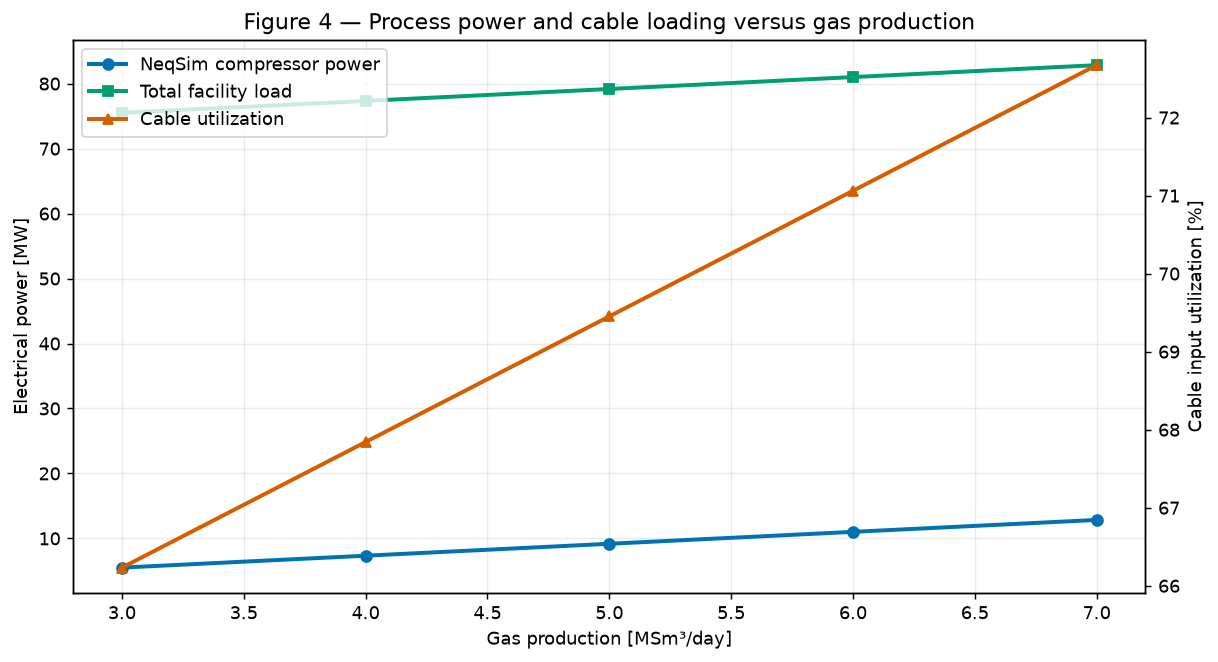

In [12]:
fig, left_axis = plt.subplots(figsize=(9.5, 5.2))
right_axis = left_axis.twinx()

left_axis.plot(
    integrated_results["production_rate_msm3_day"],
    integrated_results["compressor_power_mw"],
    marker="o",
    linewidth=2.2,
    color=COLORS["blue"],
    label="NeqSim compressor power",
)
left_axis.plot(
    integrated_results["production_rate_msm3_day"],
    integrated_results["facility_load_mw"],
    marker="s",
    linewidth=2.2,
    color=COLORS["green"],
    label="Total facility load",
)
right_axis.plot(
    integrated_results["production_rate_msm3_day"],
    100.0 * integrated_results["cable_utilization"],
    marker="^",
    linewidth=2.2,
    color=COLORS["red"],
    label="Cable utilization",
)

left_axis.set_title(
    "Figure 4 — Process power and cable loading versus gas production"
)
left_axis.set_xlabel("Gas production [MSm³/day]")
left_axis.set_ylabel("Electrical power [MW]")
right_axis.set_ylabel("Cable input utilization [%]")
left_axis.grid(alpha=0.25)
left_handles, left_labels = left_axis.get_legend_handles_labels()
right_handles, right_labels = right_axis.get_legend_handles_labels()
left_axis.legend(
    left_handles + right_handles,
    left_labels + right_labels,
    loc="upper left",
)
plt.tight_layout()
plt.show()

Compressor power rises linearly with rate here because state specifications and
efficiency are fixed. Vendor maps, staging, and anti-surge recycle can make the
relationship nonlinear. The pressure sweep similarly shows that export requirements
must be coupled back to electrical design.

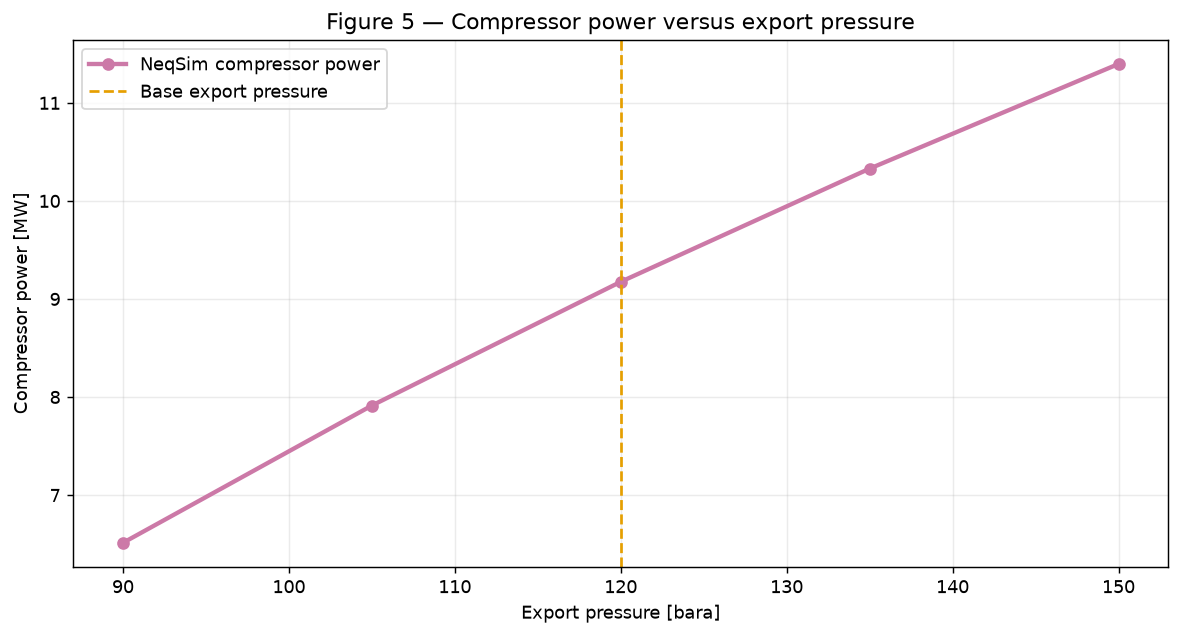

In [13]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.plot(
    pressure_results["outlet_pressure_bara"],
    pressure_results["compressor_power_mw"],
    marker="o",
    linewidth=2.4,
    color=COLORS["purple"],
    label="NeqSim compressor power",
)
ax.axvline(
    120.0,
    color=COLORS["orange"],
    linestyle="--",
    label="Base export pressure",
)
ax.set_title("Figure 5 — Compressor power versus export pressure")
ax.set_xlabel("Export pressure [bara]")
ax.set_ylabel("Compressor power [MW]")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Applicability, limitations, references, and exercises

Use this notebook to learn current PyPSA construction, define a clean NeqSim-to-grid
contract, and screen dispatch and process-power sensitivities. Do not use the
synthetic values for market forecasting, grid connection, cable design, compressor
selection, or emissions reporting.

Next steps:

1. run official PyPSA-Earth with a pinned release and Norway configuration, then
   replace the compact builder with its generated network;
2. fix cable rating and find maximum feasible production;
3. add offshore wind, storage, time-varying loads, and N-1 constraints; and
4. add compressor maps, staging, intercooling, and anti-surge recycle in NeqSim.

References:

- [PyPSA optimization](https://docs.pypsa.org/latest/user-guide/network-optimization/)
- [Network.optimize API](https://docs.pypsa.org/latest/api/networks/optimize/)
- [PyPSA-Earth installation](https://pypsa-earth.readthedocs.io/en/latest/home/installation/)
- [PyPSA-Earth repository](https://github.com/pypsa-meets-earth/pypsa-earth)
- [NeqSim process examples](https://equinor.github.io/neqsim/process/optimization/PRACTICAL_EXAMPLES)
- [NeqSim compressor documentation](https://equinor.github.io/neqsim/process/equipment/compressor_curves)

In [14]:
engineering_checks = {
    "baseline_optimization_optimal": (
        str(norway_network.model.termination_condition) == "optimal"
    ),
    "baseline_electrical_closure": (
        abs(electrical_residual_mwh) < 1.0e-6
    ),
    "baseline_cable_delivery_matches_load": bool(
        np.allclose(cable_output, offshore_load, atol=1.0e-8)
    ),
    "baseline_corridors_within_rating": bool(
        line_utilization.max() <= 1.0 + 1.0e-8
    ),
    "rate_power_trend_positive": bool(
        np.diff(rate_results["compressor_power_mw"]).min() > 0.0
    ),
    "pressure_power_trend_positive": bool(
        np.diff(pressure_results["compressor_power_mw"]).min() > 0.0
    ),
    "process_mass_balances_closed": bool(
        max(
            rate_results["mass_residual"].max(),
            pressure_results["mass_residual"].max(),
        )
        < 1.0e-10
    ),
    "integrated_electrical_balances_closed": bool(
        integrated_results["electrical_residual_mwh"].abs().max()
        < 1.0e-6
    ),
    "integrated_cables_within_rating": bool(
        integrated_results["cable_utilization"].max()
        <= 1.0 + 1.0e-8
    ),
    "all_integrated_results_finite": bool(
        np.isfinite(
            integrated_results.select_dtypes(include="number").to_numpy()
        ).all()
    ),
}

if not all(engineering_checks.values()):
    failed_checks = [
        name
        for name, passed in engineering_checks.items()
        if not passed
    ]
    raise AssertionError(f"Failed engineering checks: {failed_checks}")

check_table = pd.DataFrame(
    {
        "engineering_check": list(engineering_checks),
        "passed": list(engineering_checks.values()),
    }
)
display(check_table)
print(
    f"Engineering checks passed: {sum(engineering_checks.values())}/"
    f"{len(engineering_checks)}"
)

Engineering checks passed: 10/10


,engineering_check,passed
0,baseline_optimization_optimal,True
1,baseline_electrical_closure,True
2,baseline_cable_delivery_matches_load,True
3,baseline_corridors_within_rating,True
4,rate_power_trend_positive,True
5,pressure_power_trend_positive,True
6,process_mass_balances_closed,True
7,integrated_electrical_balances_closed,True
8,integrated_cables_within_rating,True
9,all_integrated_results_finite,True


## Conclusion

Both original examples now run with current APIs and explicit checks. The synthetic
network demonstrates an intentional transfer constraint and a correctly sized
100 MW offshore connection. NeqSim 3.16.0 supplies process power from a reusable
flowsheet, and each rate is passed to a fresh PyPSA optimization.